In [9]:
import pandas as pd

df = pd.read_csv("adult/adult.data", header=None, index_col=False)
col_names = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]
df.columns = col_names
display(df)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


## Question 1 - Demographic Parity
Compute the difference between the proportion of identified-as-male with an income greater than 50k and the proportion of identified-as-female with an income greater than 50k. Does the data seem fair by this measure?

This measure is not exactly demographic parity, since we are not making a prediction: We are just computing the “fairness” of the input data itself. So, we are substituting the true income for the predicted income.

In [12]:
# Remove whitespace from income values
df['income'] = df['income'].str.strip()
df['sex'] = df['sex'].str.strip()
male_high_income = (df['sex'] == 'Male') & (df['income'] == '>50K')
female_high_income = (df['sex'] == 'Female') & (df['income'] == '>50K')

prop_male = male_high_income.sum() / (df['sex'] == 'Male').sum()
prop_female = female_high_income.sum() / (df['sex'] == 'Female').sum()

diff = prop_male - prop_female
print(f"Proportion Male >50K: {prop_male:.3f}")
print(f"Proportion Female >50K: {prop_female:.3f}")
print(f"Difference: {diff:.3f}")

# Fairness interpretation
if abs(diff) < 0.05:
    print("The data seems relatively fair by this measure.")
else:
    print("The data shows a notable difference by sex in high income.")

Proportion Male >50K: 0.306
Proportion Female >50K: 0.109
Difference: 0.196
The data shows a notable difference by sex in high income.


In [21]:
highest_rate = prop_male
threshold = 0.8 * highest_rate  # 80% of highest rate
print(f"80% of {highest_rate:.2f} is {threshold:.2f}")

80% of 0.31 is 0.24


### Answer
Using the 5% rule the data does not seem to be fair by this measure.<p>
Using the 80/20 rule, the female group is smaller than 80% of the male group, so this would indicate it is not fair as well.<p>

## Question 2 - Conditional Statistical Parity
Compute the difference between the proportion of identified-as-male with a Doctorate with an income greater than 50k dollars and the proportion of identified-as-female with a Doctorate with an income greater than 50k. Does the data seem fair by this measure?

In [23]:
# Remove whitespace from income values
df['education'] = df['education'].str.strip()

male_high_income = (df['sex'] == 'Male') & (df['income'] == '>50K') & (df['education'] == 'Doctorate')
female_high_income = (df['sex'] == 'Female') & (df['income'] == '>50K') & (df['education'] == 'Doctorate')

prop_male = male_high_income.sum() / (df['sex'] == 'Male').sum()
prop_female = female_high_income.sum() / (df['sex'] == 'Female').sum()

diff = prop_male - prop_female
print(f"Proportion Male Doctoral >50K: {prop_male:.3f}")
print(f"Proportion Female Doctoral >50K: {prop_female:.3f}")
print(f"Difference: {diff:.3f}")

# Fairness interpretation
if abs(diff) < 0.05:
    print("The data seems relatively fair by this measure.")
else:
    print("The data shows a notable difference by sex in high income.")

Proportion Male Doctoral >50K: 0.012
Proportion Female Doctoral >50K: 0.005
Difference: 0.007
The data seems relatively fair by this measure.


## Question 3
Now, train a model to predict whether the income is above or below 50k. You may find this Adult Income Classification notebookLinks to an external site. helpful. You will need to differentiate between your predicted outcomes (income > $50k, or not) relative to the true outcome in the dataset.

Report the accuracy of your trained classifier.

In [28]:
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

#Check if there are missing values in the dataset and delete the data if so
data = df.copy()
for x in data.columns:
    mv = data[x].isin(["?"]).sum()
    if mv > 0:
        data = data[data[x] != '?']

data.workclass = data.workclass.replace({'Self-emp-not-inc': 'Self-emp',
                                        'Self-emp-inc': 'Self-emp',
                                        'Local-gov': 'Gov',
                                        'Federal-gov': 'Gov',
                                        'State-gov': 'Gov'})
data.education = data.education.replace({'Preschool': 'No-school',
                                        '1st-4th': 'No-school',
                                        '5th-6th': 'No-school',
                                        '7th-8th': 'No-school',
                                        '9th': 'No-school',
                                        '10th': 'No-school',
                                        '11th': 'No-school',
                                        '12th': 'No-school',
                                        'Some-college': 'College',
                                        'Assoc-voc': 'College',
                                        'Assoc-acdm': 'College'})
data['marital-status'].replace(['Married-civ-spouse'], 'Married', inplace=True)
data['marital-status'].replace('Never-married', 'Not-married', inplace=True)
data['marital-status'].replace(['Divorced'], 'Separated', inplace=True)
data['marital-status'].replace(['Separated'], 'Separated', inplace=True)
data['marital-status'].replace(['Married-spouse-absent'], 'Not-married', inplace=True)
data['marital-status'].replace(['Married-AF-spouse'], 'Married', inplace=True)
data['native-country'].replace(['United-States'], 'N-America', inplace=True)
data['native-country'].replace(['Mexico'], 'N-America', inplace=True)
data['native-country'].replace(['Philippines'], 'Asia', inplace=True)
data['native-country'].replace(['Germany'], 'Europe', inplace=True)
data['native-country'].replace(['Puerto-Rico'], 'N-America', inplace=True)
data['native-country'].replace(['Canada'], 'N-America', inplace=True)
data['native-country'].replace(['India'], 'Asia', inplace=True)
data['native-country'].replace(['El-Salvador'], 'MS-America', inplace=True)
data['native-country'].replace(['Cuba'], 'MS-America', inplace=True)
data['native-country'].replace(['England'], 'Europe', inplace=True)
data['native-country'].replace(['Jamaica'], 'MS-America', inplace=True)
data['native-country'].replace(['Italy'], 'Europe', inplace=True)

data['native-country'].replace(['China'], 'Asia', inplace=True)
data['native-country'].replace(['Dominican-Republic'], 'MS-America', inplace=True)
data['native-country'].replace(['Vietnam'], 'Asia', inplace=True)
data['native-country'].replace(['Guatemala'], 'MS-America', inplace=True)
data['native-country'].replace(['Japan'], 'Asia', inplace=True)
data['native-country'].replace(['Columbia'], 'MS-America', inplace=True)
data['native-country'].replace(['Poland'], 'Europe', inplace=True)
data['native-country'].replace(['Taiwan'], 'Asia', inplace=True)
data['native-country'].replace(['Haiti'], 'MS-America', inplace=True)
data['native-country'].replace(['Iran'], 'Asia', inplace=True)
data['native-country'].replace(['Portugal'], 'Europe', inplace=True)
data['native-country'].replace(['Nicaragua'], 'MS-America', inplace=True)

data['native-country'].replace(['Peru'], 'MS-America', inplace=True)
data['native-country'].replace(['Greece'], 'Europe', inplace=True)
data['native-country'].replace(['Ecuador'], 'MS-America', inplace=True)
data['native-country'].replace(['France'], 'Europe', inplace=True)
data['native-country'].replace(['Ireland'], 'Europe', inplace=True)
data['native-country'].replace(['Hong'], 'Asia', inplace=True)
data['native-country'].replace(['Trinadad&Tobago'], 'MS-America', inplace=True)
data['native-country'].replace(['Cambodia'], 'Asia', inplace=True)
data['native-country'].replace(['Laos'], 'Asia', inplace=True)
data['native-country'].replace(['Thailand'], 'Asia', inplace=True)
data['native-country'].replace(['Yugoslavia'], 'Europe', inplace=True)
data['native-country'].replace(['Outlying-US(Guam-USVI-etc)'], 'N-America', inplace=True)

data['native-country'].replace(['Hungary'], 'Europe', inplace=True)
data['native-country'].replace(['Honduras'], 'MS-America', inplace=True)
data['native-country'].replace(['Scotland'], 'Europe', inplace=True)
data['native-country'].replace(['Holand-Netherlands'], 'Europe', inplace=True)
data.drop(columns=['education-num', 'fnlwgt', 'relationship'], axis=1, inplace=True)
data

,age,workclass,education,marital-status,occupation,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,White,Male,0,0,40,United-States,<=50K
3,53,Private,No-school,Married-civ-spouse,Handlers-cleaners,Black,Male,0,0,40,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,College,Married-civ-spouse,Tech-support,White,Female,0,0,38,United-States,<=50K
32557,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,White,Male,0,0,40,United-States,>50K
32558,58,Private,HS-grad,Widowed,Adm-clerical,White,Female,0,0,40,United-States,<=50K
32559,22,Private,HS-grad,Never-married,Adm-clerical,White,Male,0,0,20,United-States,<=50K


In [32]:
#Import OneHotEncoder, LabelEncoder & MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler

#Define how to process which feature
columns_to_label_encode   = ['income']
columns_to_scale          = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

#Instantiate encoder/scaler
ohe    = OneHotEncoder(sparse_output=False)
le     = LabelEncoder()
mms    = MinMaxScaler()

#To one hot encode the string values, they need to be in a numeric format,
#To do so, we first label encode those features
import numpy as np
n_rows = data.shape[0]
w = np.reshape(le.fit_transform(data['workclass']), (n_rows, 1))
e = np.reshape(le.fit_transform(data['education']), (n_rows, 1))
m = np.reshape(le.fit_transform(data['marital-status']), (n_rows, 1))
o = np.reshape(le.fit_transform(data['occupation']), (n_rows, 1))
r = np.reshape(le.fit_transform(data['race']), (n_rows, 1))
s = np.reshape(le.fit_transform(data['sex']), (n_rows, 1))
n = np.reshape(le.fit_transform(data['native-country']), (n_rows, 1))

#Concatenate the label encoded features
wemorsn = np.concatenate([w, e, m, o, r, s, n], axis=1)

#Scale and encode separate columns
one_hot_encoded_columns = ohe.fit_transform(wemorsn)
label_encoded_columns   = np.reshape(le.fit_transform(data[columns_to_label_encode]), (n_rows, 1))
min_max_scaled_columns  = mms.fit_transform(data[columns_to_scale])

#Concatenate again
processed_data = np.concatenate([min_max_scaled_columns, one_hot_encoded_columns, label_encoded_columns], axis=1)

#Turn processed data into DataFrame typ
pd_df = pd.DataFrame(processed_data, index=data.index)

pd_df.head(10)

,0,1,2,3,4,5,6,7,8,9,...,82,83,84,85,86,87,88,89,90,91
0,0.301370,0.021740,0.0,0.397959,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.452055,0.000000,0.0,0.122449,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.287671,0.000000,0.0,0.397959,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.493151,0.000000,0.0,0.397959,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.150685,0.000000,0.0,0.397959,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.273973,0.000000,0.0,0.397959,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,0.438356,0.000000,0.0,0.153061,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.479452,0.000000,0.0,0.448980,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
8,0.191781,0.140841,0.0,0.500000,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
9,0.342466,0.051781,0.0,0.397959,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


Mean accuracy on test data:
DT 0.8252725318593582
NB 0.3519115614923998
KNN 0.828650391524643
LR 0.8499923230462153
RF 0.8461538461538461
LSVM 0.8530631045601106
SSVM 0.7723015507446646
RSVM 0.8400122831260556


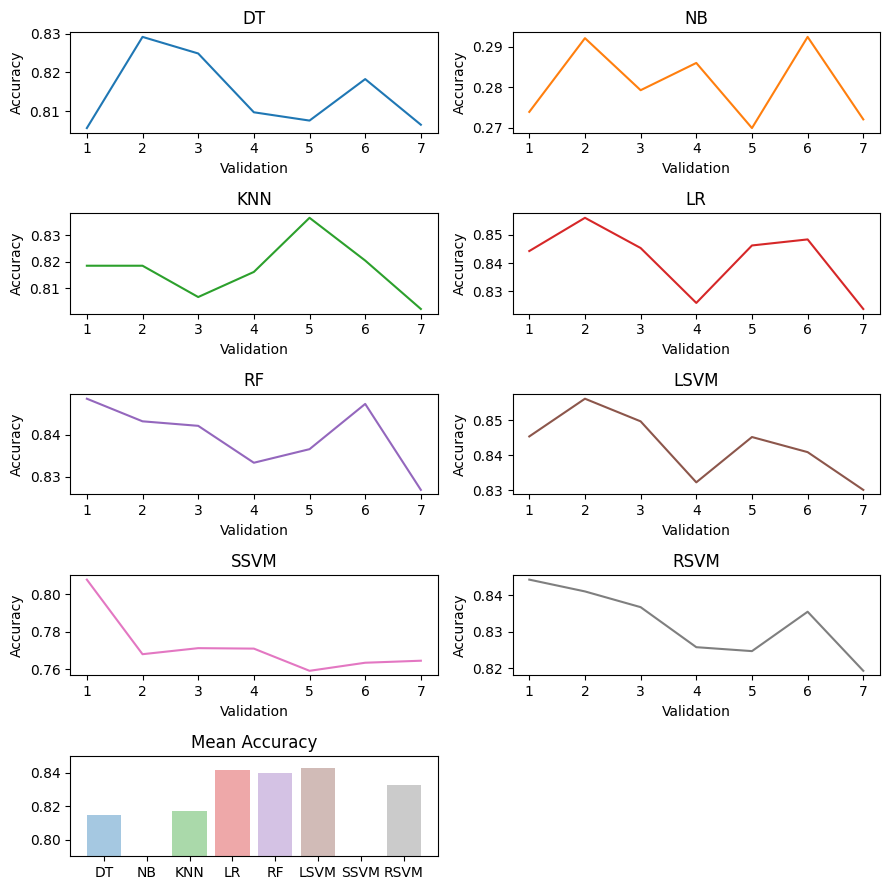

In [34]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

#Split prediction variable and features
X = processed_data[:, :-1]
y = processed_data[:, -1]

#Split test and training data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.model_selection import cross_val_score

#Import the classification models
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

#Initialize the models
models = []
models.append(('DecisionTreeClassifier', DecisionTreeClassifier()))
models.append(('GaussianNB', GaussianNB()))
models.append(('KNeighborsClassifier', KNeighborsClassifier()))
models.append(('LogisticRegression', LogisticRegression()))
models.append(('RandomForestClassifier', RandomForestClassifier()))
models.append(('linearSVM', SVC(kernel='linear')))
models.append(('sigmoidSVM', SVC(kernel='sigmoid')))
models.append(('rbfSVM', SVC(kernel='rbf')))

scores = []
names = []

#Set up charts to visualize the results
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(9, 9))
xAxis = 0
yAxis = 0

axes[4, 0].set_title('Mean Accuracy')

print('Mean accuracy on test data:')

#Train and test each model - save the results
for name, model in models:
    model.fit(X_train, y_train)
    score = cross_val_score(model, X_test, y_test, cv=7)
    scores.append(score)
    names.append(name)
    axes[xAxis, yAxis].set_title(name)
    axes[xAxis, yAxis].plot(['1','2','3','4','5','6','7'], score, color='C'+str(len(names)-1))
    axes[xAxis, yAxis].set_xlabel("Validation")
    axes[xAxis, yAxis].set_ylabel("Accuracy")
    axes[4, 0].bar(name, score.mean(), alpha=0.4, color='C'+str(len(names)-1))
    axes[4, 0].set_ylim(0.79, 0.85)

    if len(names)%2 == 1:
        yAxis += 1
    else:
        xAxis +=1
        yAxis -=1
    print(name, model.score(X_test, y_test))

#Remove empty chart
axes[4, 1].remove()

fig.tight_layout()
plt.show()

### Answer to Question 3
The best performing model is the Support Vector Machine with a linear kernel. LSVM is simple and robust. The data must have been easily separable.

## Question 4 - Predictive Parity
Compute the proportion of identified-as-male with a true income less than 50k that were predicted to have an income greater than 50k. Do the same for identified-as-female, and compute the difference. A high difference indicates more unfairness. Does the data seem fair by this measure?

In [35]:
# Use the best model (linear SVM)
best_model = SVC(kernel='linear')
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Get test indices in original data
test_indices = y_test.astype(int)

# Get gender and true income for test set
sex_test = data.iloc[X_test.shape[0]*-1:]['sex'].values
income_test = data.iloc[X_test.shape[0]*-1:]['income'].values

# Mask for true income <=50K
true_low_income = (income_test == '<=50K')

# Male group
male_mask = (sex_test == 'Male') & true_low_income
male_pred_high = (y_pred[male_mask] == 1).sum()
male_total = male_mask.sum()
prop_male = male_pred_high / male_total if male_total > 0 else np.nan

# Female group
female_mask = (sex_test == 'Female') & true_low_income
female_pred_high = (y_pred[female_mask] == 1).sum()
female_total = female_mask.sum()
prop_female = female_pred_high / female_total if female_total > 0 else np.nan

diff = prop_male - prop_female

print(f"Proportion Male (true <=50K, predicted >50K): {prop_male:.3f}")
print(f"Proportion Female (true <=50K, predicted >50K): {prop_female:.3f}")
print(f"Difference: {diff:.3f}")

if abs(diff) < 0.05:
    print("The data seems relatively fair by this measure.")
else:
    print("The data shows a notable difference by sex in misclassification.")

Proportion Male (true <=50K, predicted >50K): 0.185
Proportion Female (true <=50K, predicted >50K): 0.196
Difference: -0.011
The data seems relatively fair by this measure.


## Question 5 - Equalized Odds
Compute the proportion of identified-as-male with a predicted income less than 50k that have true income greater than 50k. Do the same for identified-as-female, and compute the difference. Does the data seem fair by this measure?

In [38]:
# Get predicted <=50K (y_pred == 0)
pred_low_income = (y_pred == 0)

# True income >50K in test set
true_high_income = (income_test == '>50K')

# Male group
male_mask = (sex_test == 'Male') & pred_low_income
male_fn = (true_high_income[male_mask]).sum()
male_total = male_mask.sum()
prop_male = male_fn / male_total if male_total > 0 else float('nan')

# Female group
female_mask = (sex_test == 'Female') & pred_low_income
female_fn = (true_high_income[female_mask]).sum()
female_total = female_mask.sum()
prop_female = female_fn / female_total if female_total > 0 else float('nan')

diff = prop_male - prop_female

print(f"Proportion Male (pred <=50K, true >50K): {prop_male:.3f}")
print(f"Proportion Female (pred <=50K, true >50K): {prop_female:.3f}")
print(f"Difference: {diff:.3f}")

if abs(diff) < 0.05:
    print("The data seems relatively fair by this measure.")
else:
    print("The data shows a notable difference by sex in false negatives.")

Proportion Male (pred <=50K, true >50K): 0.312
Proportion Female (pred <=50K, true >50K): 0.115
Difference: 0.197
The data shows a notable difference by sex in false negatives.


# Answer - Summary
Of the four measures of fairness we considered: Demographic Parity, Conditional Statistical Parity, Predictive Parity, Equalized Odds, the least fair was the Demographic Parity measure. Equalized odds was also questionably fair. The most fair was Predictive Parity followed closely by Conditional Statistical Parity.